# Transmitter Validation and Nonlinearity Analysis for an Optical IQ Modulator

## Objective

The goal of this analysis is to validate the **transmitter-side behavior of an optical IQ modulator (IQM)** used to generate a **16-QAM optical signal**.

The drive voltage of the IQM is treated as a separate variable from the Power Amplifier (PA) to isolate its non-linear effects. A scaling factor is applied directly to the drive voltage, allowing independent investigation of the IQM’s performance. This approach enables a clearer understanding of how drive-level scaling influences the generation of nonlinear distortions.

The transmitter must:

1. Correctly implement **IQ modulation**
2. Operate at the correct **bias point**
3. Produce a **controlled amount of nonlinear distortion**
4. Provide measurable distortion suitable for **Digital Predistortion (DPD)** compensation

Only the **transmitter chain** is analyzed.  
The receiver is used solely as a **measurement tool** to evaluate transmitter distortion.

---

# Optical Transmitter Architecture

The transmitter consists of the following components:

1. Symbol generation (16-QAM)
2. Pulse shaping (Root Raised Cosine)
3. Electrical waveform normalization
4. IQ modulation using a **dual Mach–Zehnder modulator**
5. Optical carrier modulation

The IQ modulator converts the complex baseband signal into an optical field.


In [20]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [21]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [22]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent. Paper uses p=2.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """

    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """

    wn = f3dB / (Fs / 2)  # normalized cutoff
    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    # This function creates the coefficients of the Butterworth filter
    # b = numerator coefficient
    # a = denumerator coefficients
    b, a = signal.butter(order, wn, btype='low')

    # Apply the filter at the real and complex parts seperately
    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    # Recombine the signal
    return y_i + 1j * y_q


def pa_model(x, Fs, BO_dB=5.0, p=2.0, f3dB=37e9):
    """
    Paper-style PA model:
        x -> Rapp nonlinearity -> 3rd-order Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform.
    Fs : float
        Sample rate [Hz].
    BO_dB : float
        Back-off setting in dB. Use 7, 5, 3 for weak/moderate/strong.
    p : float
        Rapp exponent. Paper uses p=2.
    f3dB : float
        PA 3-dB bandwidth [Hz]. Paper uses 37 GHz.

    Returns
    -------
    y : np.ndarray
        PA output waveform.
    info : dict
        Diagnostic information.
    """

    # Calculate the RMS voltage of the electrical complex waveform (sigTx)
    Vrms = np.sqrt(np.mean(np.abs(x) ** 2))

    # Use back-off definition so smaller BO => stronger nonlinearity
    # Vsat larger than Vrms for weakly nonlinear operation.
    Vsat = Vrms * 10 ** (BO_dB / 20)

    y_nl = rapp_pa(x, Vsat=Vsat, p=p)
    y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=3)

    # Define PA info
    info = {
        "Vrms_in": Vrms,
        "Vsat": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB
    }
    return y, info


In [23]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QAM -> M=16, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0       # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones(sigTx_length, dtype=complex)

# 6) PA parameters 
PA_enable = False    # enable flag. If "False", the PA is skipped
PA_BO_dB = 5        # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB

# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = 0                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 0         # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 1

In [24]:
# ----------------------------------------------
# Simulation of the Optical System
# -----------------------------------------------

def simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramLO, paramFE, paramPD, paramRxPulse, paramDec, mzmScale):

    """
   This function simulates the optical transmission of a single-polarization, 
   single-channel 16/4-QAM signal.

    Parameters
    ----------
    Uses Global Parameters defined above

    Returns
    -------
    y_CPR_1 : 
        Received signal at end of DSP chain (after CPR)
    d:
        Noemlaized Symbol Synchronization with the SymbTx. Used in calculations.
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Perform Upsampling + Pulse Shaping (RRC)
    pulse = pulseShape(paramPulse)           # create pulse
    symbolsUp = upsample(symbTx, SpS)        # shape: (nSymbols*SpS,)
    sigTx = firFilter(pulse, symbolsUp)      # pulse-shaped baseband waveform  

    # sigTx = sigTx / np.max(np.abs(sigTx))    # normalize waveform to peak amplitude 1 (NOT RMS). This makes drive scaling predictable.

    # 3) Power Amplifier PA & 3rd-Order Butterworth LPF
    if PA_enable:
        sigTx_PA, paInfo = pa_model(sigTx, Fs=Fs, BO_dB=PA_BO_dB, p=PA_p, f3dB=PA_f3dB)
    else:
        sigTx_PA = sigTx.copy()

    sigTx_PA = sigTx_PA / np.max(np.abs(sigTx_PA))

    # 4) IQ Modulation: Electrical -> Optical Domain Conversion
    u_drive = Vpi * mzmScale * sigTx_PA
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    #print("=== Total MZM voltage validation ===")
    #print(f"I-arm total voltage range = [{np.min(u_drive.real + paramIQM.VbI):.4f}, {np.max(u_drive.real + paramIQM.VbI):.4f}] V")
    #print(f"Q-arm total voltage range = [{np.min(u_drive.imag + paramIQM.VbQ):.4f}, {np.max(u_drive.imag + paramIQM.VbQ):.4f}] V")
    #print(f"I-arm total normalized range = [{np.min((u_drive.real + paramIQM.VbI)/paramIQM.Vpi):.4f}, {np.max((u_drive.real + paramIQM.VbI)/paramIQM.Vpi):.4f}]")
    #print(f"Q-arm total normalized range = [{np.min((u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi):.4f}, {np.max((u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi):.4f}]")

    # 5) Set Launched Optical Power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    # Parameter which might change so needs to be in the function
    paramLO.Ns = len(sigTxo)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent Reciever for single-polarization.
    # Contains a 90 hybrid, two balanced photodiodes and iqmixing
    sigRxFrontEnd = coherentReceiver(sigTxo, sigLO_Rx, paramFE, paramPD)
    
    # 3) Pusleshaping Function
    pulse = pulseShape(paramRxPulse) 
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    return u_drive, sigTx, sigTxo, sigRxPulseShape, sigRxDecimation

In [25]:
# Plotting functions for the IQM

def plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive):
    
    v_axis = np.linspace(-4*paramIQM.Vpi, 4*paramIQM.Vpi, 2000)
    transfer = np.cos((np.pi/(2*paramIQM.Vpi)) * v_axis)

    plt.figure(figsize=(9,4))

    plt.plot(v_axis/paramIQM.Vpi, transfer, label='MZM field transfer')
    
    plt.axvspan(np.min(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, np.max(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, alpha=0.25, label='I-arm operating range')
    plt.axvspan(np.min(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, np.max(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, alpha=0.25, label='Q-arm operating range')

    plt.axvline(paramIQM.VbI/paramIQM.Vpi,color='red', linestyle='--', linewidth=2, label='Bias point')
    plt.xlabel(r'Total branch voltage / $V_\pi$')
    plt.ylabel('Field transfer')
    plt.title('Where the drive signal operates on the MZM transfer curve')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_histogram_of_IQM_branches(u_drive):  

    xI = (u_drive.real + paramIQM.VbI)/paramIQM.Vpi
    xQ = (u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(xI, bins=100, density=True)
    plt.title("I branch normalized voltage")
    plt.xlabel("(uI+VbI)/Vpi")

    plt.subplot(1,2,2)
    plt.hist(xQ, bins=100, density=True)
    plt.title("Q branch normalized voltage")
    plt.xlabel("(uQ+VbQ)/Vpi")

    plt.tight_layout()
    plt.show()

def EVM_vs_mzmScale_plot(mzmScale_list, EVM_list):
    plt.figure(figsize=(7,4))
    plt.plot(mzmScale_list, np.array(EVM_list)*100, 'o-', linewidth=2)
    plt.xlabel('mzmScale')
    plt.ylabel('EVM [%]')
    plt.title('Tx-side EVM vs IQM modulation depth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()  

def plot_am_am(sigTx, sigTxo):

    amp_in = np.abs(sigTx)
    amp_out = np.abs(sigTxo)

    plt.figure(figsize=(6,5))
    plt.scatter(amp_in, amp_out, s=2, alpha=0.3)

    plt.xlabel("Input amplitude |s(t)|")
    plt.ylabel("Output optical amplitude |E(t)|")
    plt.title("AM-AM distortion (Tx nonlinearity)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [26]:
def print_tx_metrics(u_drive, sigTxo, paramIQM, mzmScale, EVM):
    """
    Minimal Tx-side validation metrics for the IQM transmitter.
    """

    print("\n===== TX VALIDATION =====\n")

    # 1) Peak RF drive relative to Vpi
    peak_rf_drive = np.max(np.abs(u_drive)) / paramIQM.Vpi
    print(f"mzmScale                  : {mzmScale:.3f}")
    print(f"Peak RF drive / Vpi       : {peak_rf_drive:.3f}")

    # 2) Total branch voltage ranges relative to Vpi
    vI_norm = (u_drive.real + paramIQM.VbI) / paramIQM.Vpi
    vQ_norm = (u_drive.imag + paramIQM.VbQ) / paramIQM.Vpi

    print(f"I voltage range / Vpi     : [{np.min(vI_norm):.3f} , {np.max(vI_norm):.3f}]")
    print(f"Q voltage range / Vpi     : [{np.min(vQ_norm):.3f} , {np.max(vQ_norm):.3f}]")

    # 3) Max absolute normalized total voltage
    max_norm_total = max(np.max(np.abs(vI_norm)), np.max(np.abs(vQ_norm)))
    print(f"Max |(u+Vb)/Vpi|          : {max_norm_total:.3f}")

    # 4) Optical power metrics
    opt_power = np.abs(sigTxo) ** 2
    mean_opt_power = np.mean(opt_power)
    print(f"Mean optical power        : {mean_opt_power:.4e}")

    # 5) EVM printing
    print('EVM                       : %.3f %%'%(EVM[0]*100))

    print("\n=========================\n")

In [27]:
def evm_calc(symbTx, received):
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
    EVM = calcEVM(received[ind], M, 'qam', d[ind])

    return EVM
   

# Experiment:
Vary the mzmScale and measure the effect on the EVM and visualize through the constellation diagram

mzmScale Sweep:   0%|          | 0/7 [00:00<?, ?it/s]

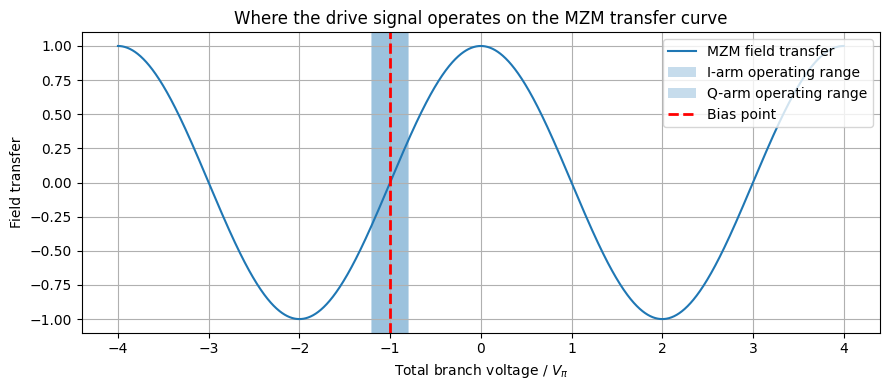

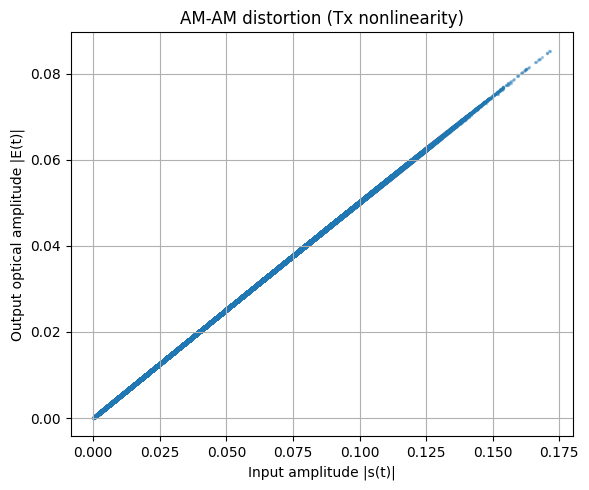

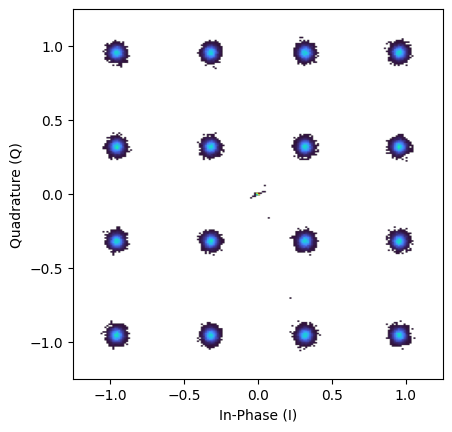


===== TX VALIDATION =====

mzmScale                  : 0.250
Peak RF drive / Vpi       : 0.250
I voltage range / Vpi     : [-1.200 , -0.801]
Q voltage range / Vpi     : [-1.213 , -0.795]
Max |(u+Vb)/Vpi|          : 1.213
Mean optical power        : 1.0000e-03
EVM                       : 0.118 %




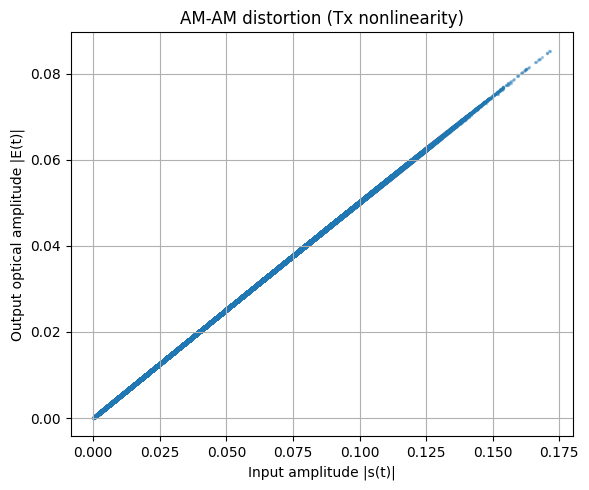

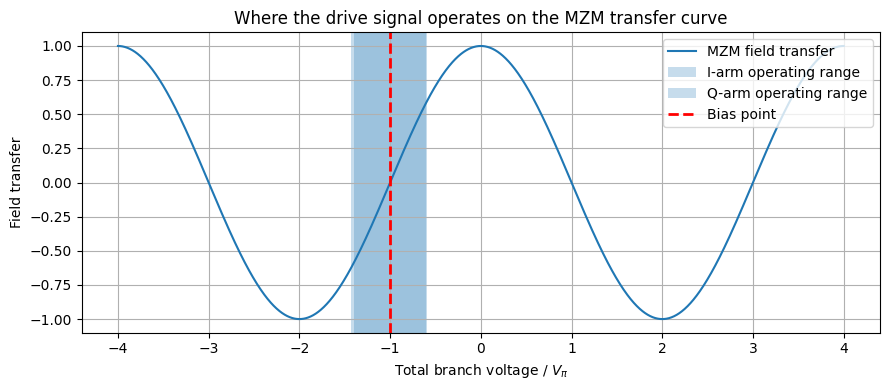

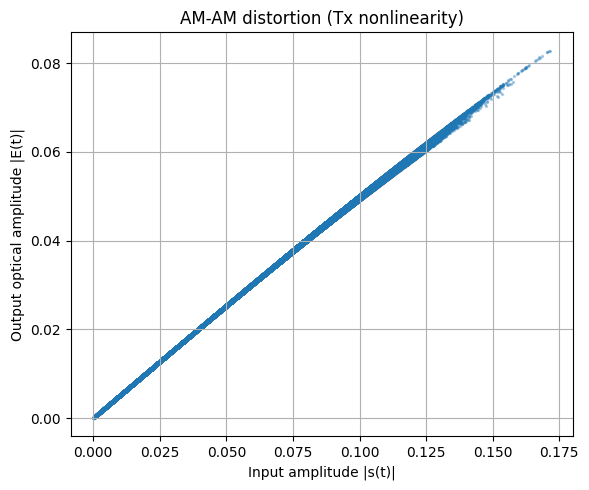

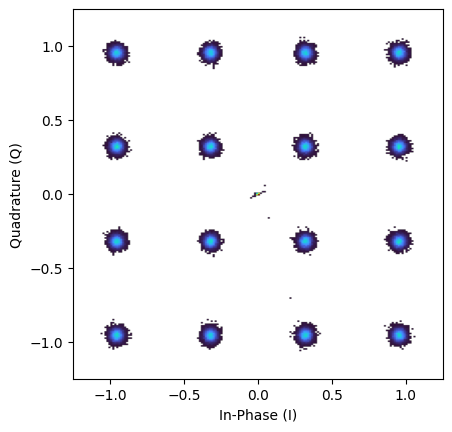


===== TX VALIDATION =====

mzmScale                  : 0.500
Peak RF drive / Vpi       : 0.500
I voltage range / Vpi     : [-1.400 , -0.603]
Q voltage range / Vpi     : [-1.426 , -0.591]
Max |(u+Vb)/Vpi|          : 1.426
Mean optical power        : 1.0000e-03
EVM                       : 0.120 %




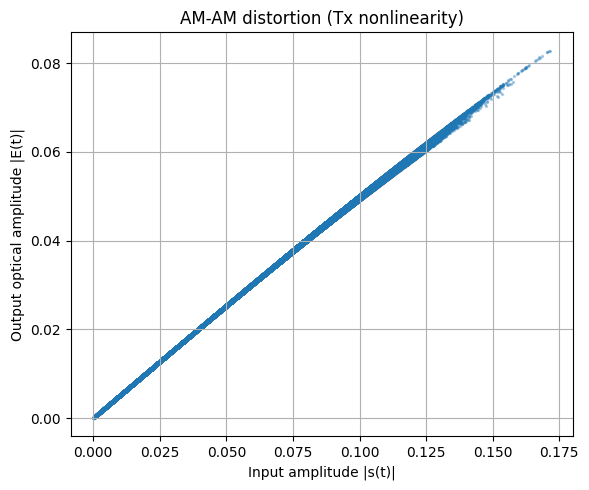

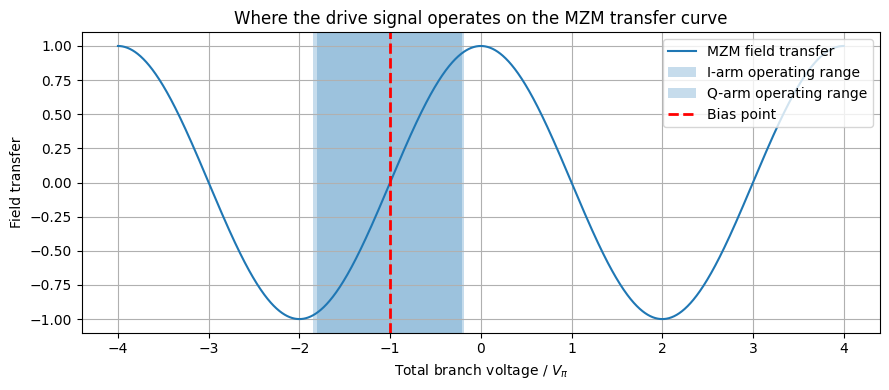

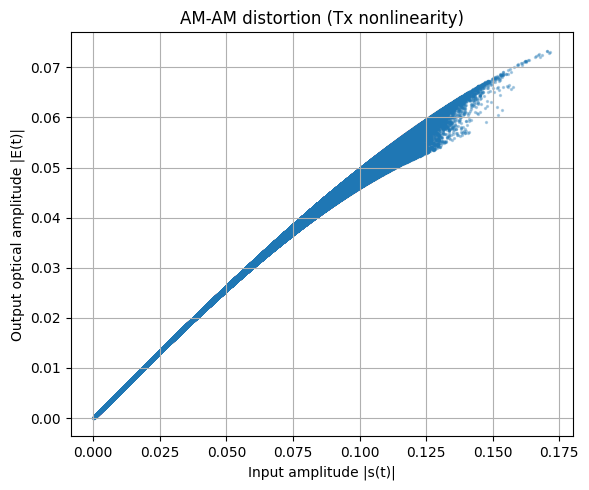

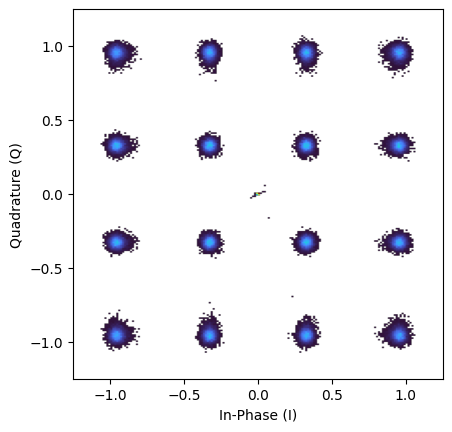


===== TX VALIDATION =====

mzmScale                  : 1.000
Peak RF drive / Vpi       : 1.000
I voltage range / Vpi     : [-1.800 , -0.205]
Q voltage range / Vpi     : [-1.853 , -0.181]
Max |(u+Vb)/Vpi|          : 1.853
Mean optical power        : 1.0000e-03
EVM                       : 0.173 %




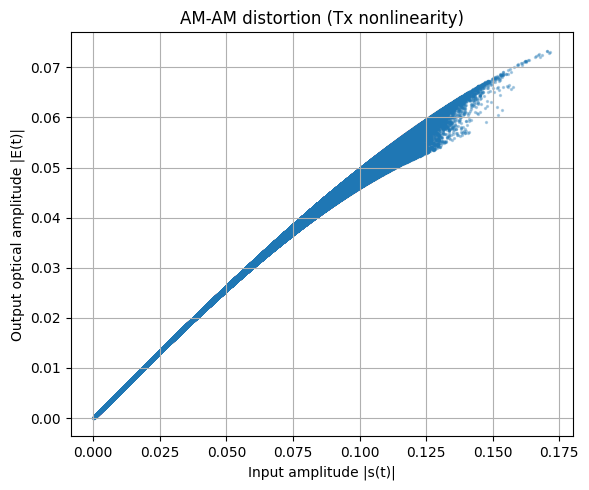

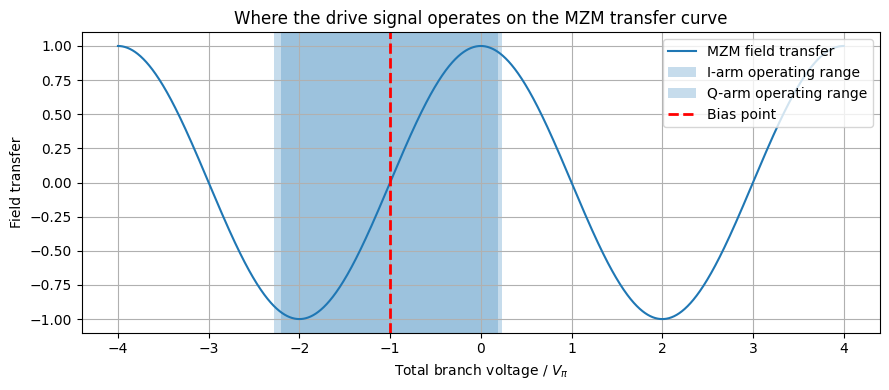

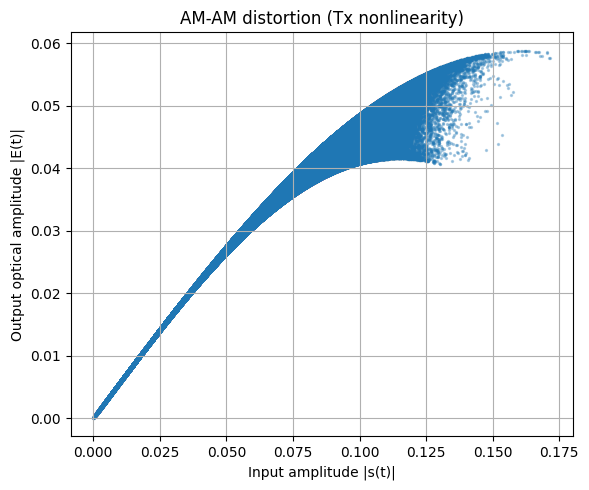

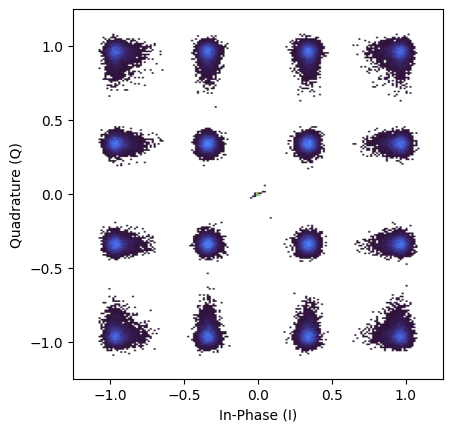


===== TX VALIDATION =====

mzmScale                  : 1.500
Peak RF drive / Vpi       : 1.500
I voltage range / Vpi     : [-2.201 , 0.192]
Q voltage range / Vpi     : [-2.279 , 0.228]
Max |(u+Vb)/Vpi|          : 2.279
Mean optical power        : 1.0000e-03
EVM                       : 0.422 %




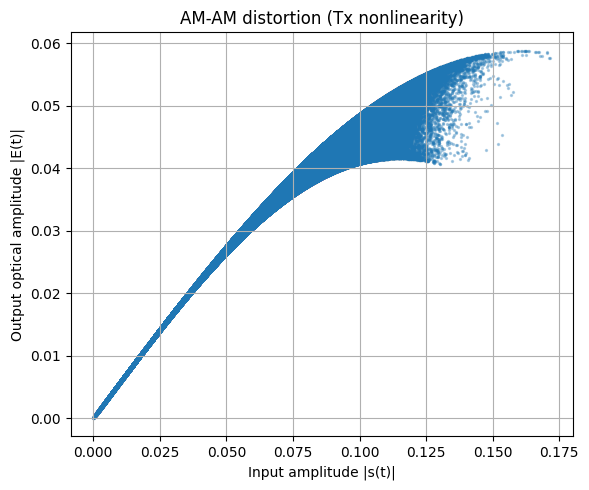

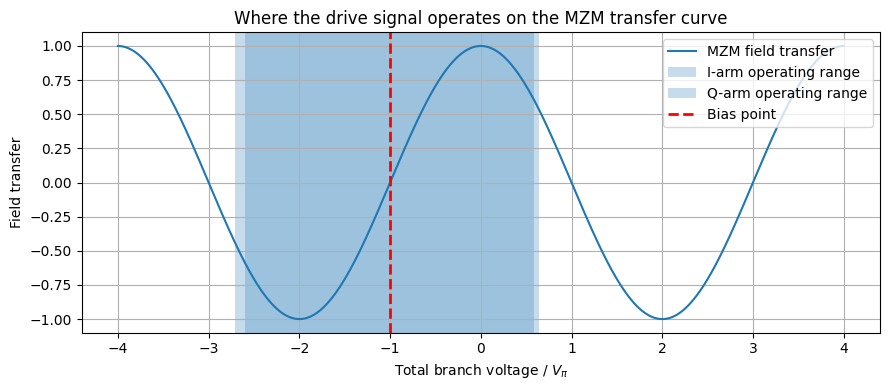

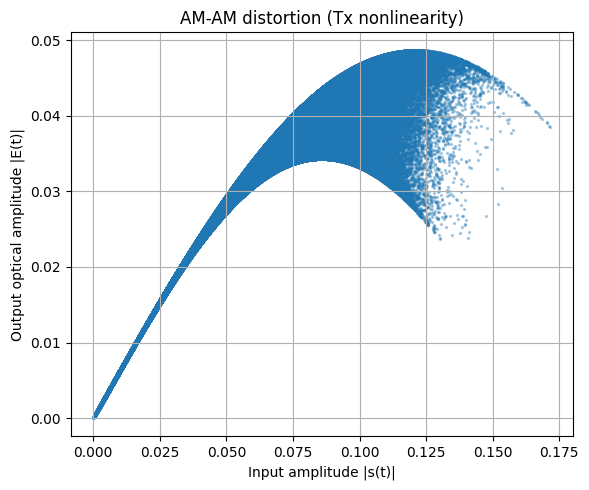

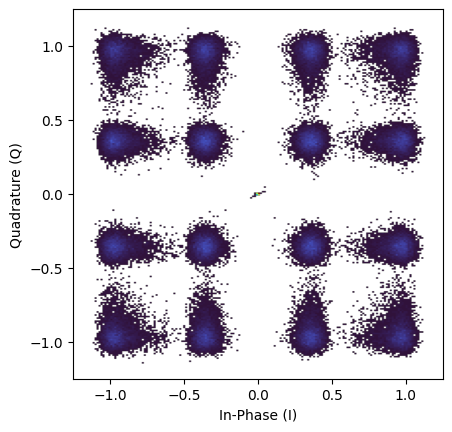


===== TX VALIDATION =====

mzmScale                  : 2.000
Peak RF drive / Vpi       : 2.000
I voltage range / Vpi     : [-2.601 , 0.590]
Q voltage range / Vpi     : [-2.705 , 0.638]
Max |(u+Vb)/Vpi|          : 2.705
Mean optical power        : 1.0000e-03
EVM                       : 1.129 %




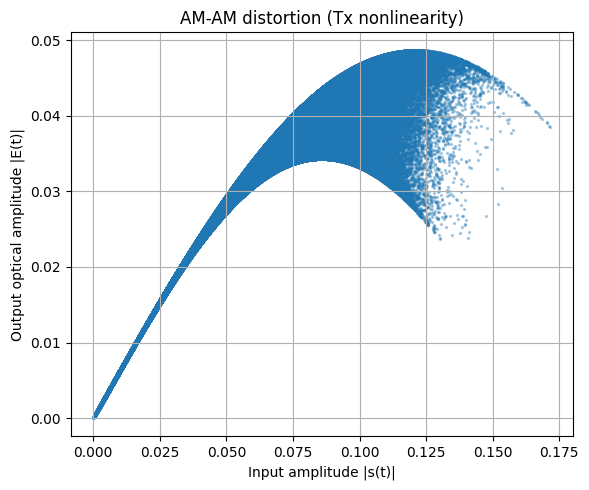

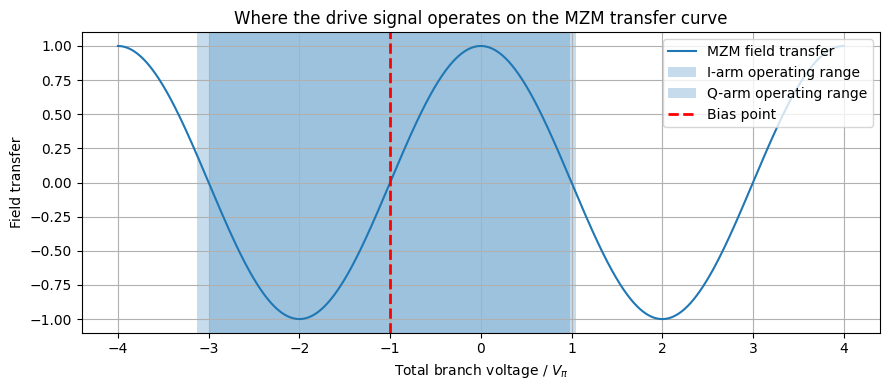

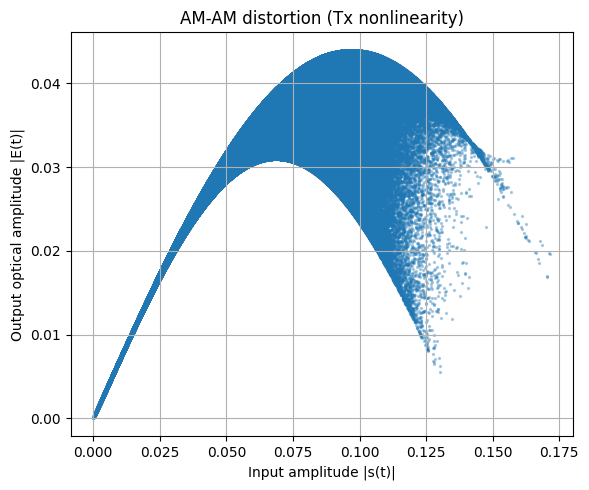

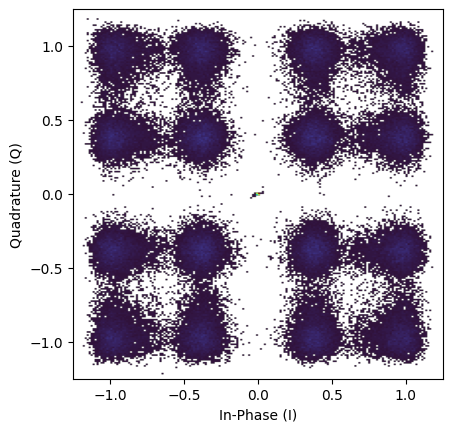


===== TX VALIDATION =====

mzmScale                  : 2.500
Peak RF drive / Vpi       : 2.500
I voltage range / Vpi     : [-3.001 , 0.987]
Q voltage range / Vpi     : [-3.132 , 1.047]
Max |(u+Vb)/Vpi|          : 3.132
Mean optical power        : 1.0000e-03
EVM                       : 2.715 %




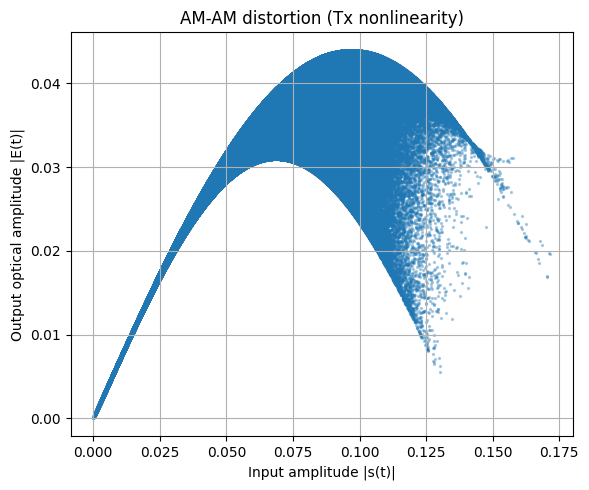

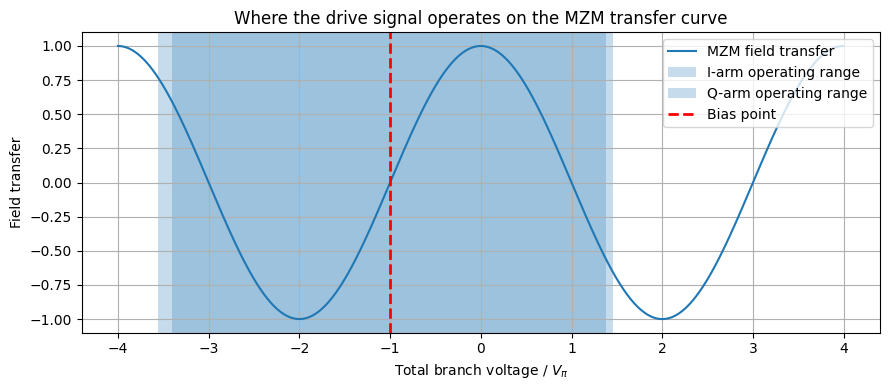

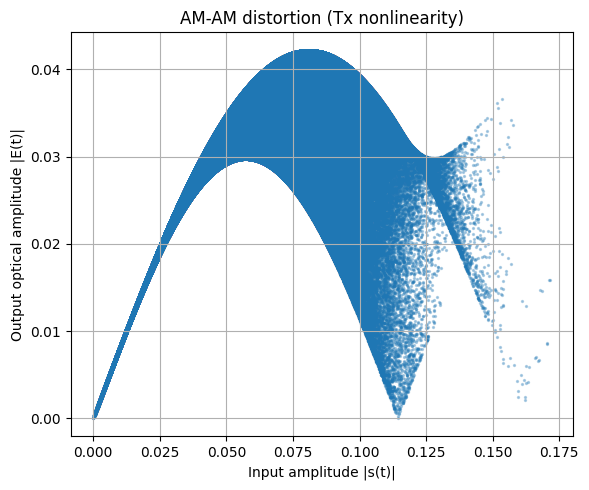

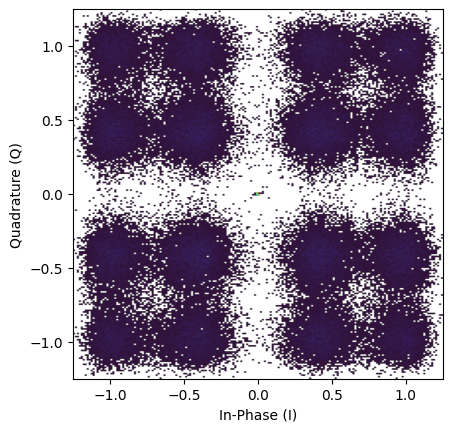


===== TX VALIDATION =====

mzmScale                  : 3.000
Peak RF drive / Vpi       : 3.000
I voltage range / Vpi     : [-3.401 , 1.385]
Q voltage range / Vpi     : [-3.558 , 1.457]
Max |(u+Vb)/Vpi|          : 3.558
Mean optical power        : 1.0000e-03
EVM                       : 5.866 %




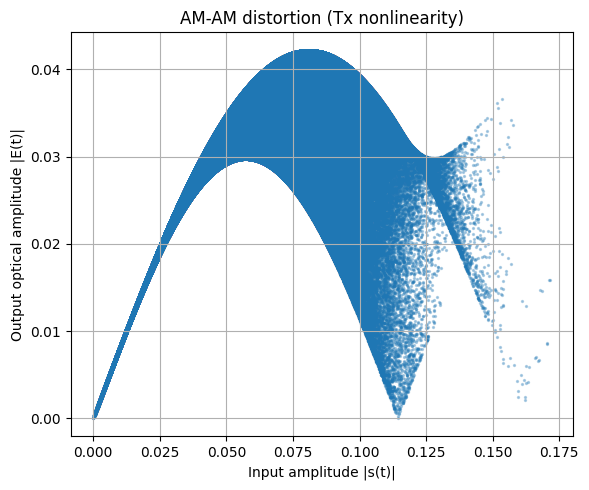

 EVM: 0.118 %
 EVM: 0.120 %
 EVM: 0.173 %
 EVM: 0.422 %
 EVM: 1.129 %
 EVM: 2.715 %
 EVM: 5.866 %


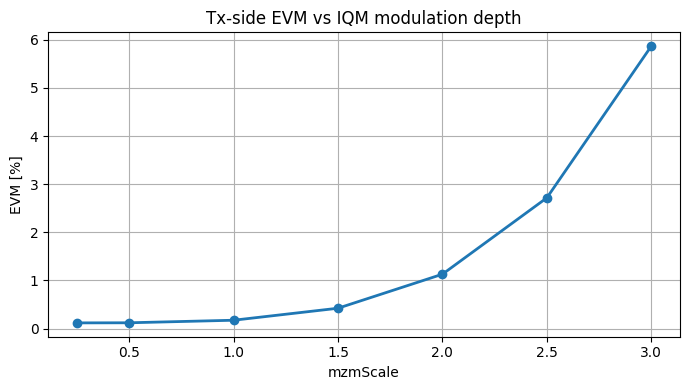

In [28]:
# IQM Anlysis

symbTx = symbolSource(paramSymb)
EVM_list = []

mzmScale_list = [0.25, 0.5, 1, 1.5, 2, 2.5, 3]

for mzmScale_value in tqdm(mzmScale_list, desc="mzmScale Sweep"):

    mzmScale = mzmScale_value
    u_drive, sigTx, sigTxo, matched, received  = simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramLO, paramFE, paramPD, paramRxPulse, paramDec, mzmScale)

    plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive)

    EVM = evm_calc(symbTx, received)
    EVM_list.append(EVM)

    plot_am_am(sigTx, sigTxo)
    pconst(received, lim=True, R=1.25, pType='fancy')

    print_tx_metrics(u_drive, sigTxo, paramIQM, mzmScale, EVM)

    plot_am_am(sigTx, sigTxo)


for i in range(len(EVM_list)):
    print(' EVM: %.3f %%' % (EVM_list[i][0]*100))

EVM_vs_mzmScale_plot(mzmScale_list, EVM_list)


# IQ Modulator Model

An IQ modulator is composed of two **Mach–Zehnder modulators (MZMs)**:

- **I branch** (in-phase component)
- **Q branch** (quadrature component)

The optical output field is

$$
E_{out} = E_I + jE_Q
$$

where each branch independently modulates the optical carrier.

---

# Mach–Zehnder Modulator Transfer Function

Each MZM follows the field transfer function

$$
E = A_i \cos\left(\frac{\pi}{2V_\pi}(u + V_b)\right)
$$

where

- $u$ = electrical drive voltage  
- $V_b$ = bias voltage  
- $V_\pi$ = half-wave voltage  
- $A_i$ = input optical amplitude  

Because the response is cosine-shaped, the modulator is **intrinsically nonlinear**.

---

# Quadrature Bias Operation

For IQ modulation the MZM is biased at the **quadrature point**:

$$
V_b = -V_\pi
$$

Substituting into the transfer function gives

$$
E_{out} = A_i \cos\left(\frac{\pi}{2V_\pi}(u - V_\pi)\right)
$$

Using the trigonometric identity

$$
\cos(x - \frac{\pi}{2}) = \sin(x)
$$

the transfer becomes

$$
E_{out} = A_i \sin\left(\frac{\pi}{2V_\pi}u\right)
$$

Thus the quadrature-biased MZM behaves as a **sine transfer function**.

---

# Small-Signal Approximation

For small arguments

$$
\sin(x) \approx x
$$

Therefore

$$
E_{out} \approx A_i \frac{\pi}{2V_\pi} u
$$

This corresponds to the **linear operating regime** of the modulator.

When the electrical drive becomes large, the sine transfer produces **nonlinear compression**.

---

# Electrical Drive Signal

The transmitter applies the following electrical drive:

$$
u(t) = V_\pi \cdot mzmScale \cdot s(t)
$$

where

- $s(t)$ = normalized baseband waveform
- `mzmScale` = modulation depth parameter

Since the waveform is normalized,

$$
\max |s(t)| = 1
$$

the maximum electrical drive is

$$
\max |u(t)| = mzmScale \cdot V_\pi
$$

Therefore **mzmScale directly controls the drive voltage relative to $V_\pi$**.

---

# Nonlinear Behavior

Substituting the drive signal into the transfer function:

$$
E_{out}(t) = A_i \sin\left(\frac{\pi}{2} mzmScale \, s(t)\right)
$$

As `mzmScale` increases:

- the sine function becomes nonlinear
- amplitude compression appears
- constellation distortion increases

These nonlinear effects are required for **DPD experiments**.

---

# Transmitter Validation Metrics

To verify correct transmitter operation, several metrics are printed during simulation.

## RF Drive Strength

$$
\frac{\max |u(t)|}{V_\pi}
$$

This indicates how strongly the modulator is driven.

Typical interpretation:

| Drive level | Behavior |
|-------------|----------|
| < 0.5 | weak modulation |
| 0.5 – 0.8 | moderate drive |
| > 1 | strong nonlinear modulation |

---

## Total Branch Voltage

The total voltage applied to each branch is

$$
\frac{u(t) + V_b}{V_\pi}
$$

This indicates **where the signal operates on the cosine transfer curve**.

Correct IQ modulation requires the signal to operate around the **quadrature region**.

---

## Optical Power Statistics

The optical field power is

$$
P(t) = |E(t)|^2
$$

The following values are measured:

- mean optical power
- peak optical power
- optical modulation depth

These metrics confirm that the optical signal is correctly normalized.

---

# Transmitter Validation Plots

Several plots are used to verify correct transmitter behavior.

---

# MZM Transfer Curve with Operating Region

The cosine transfer function of the MZM is plotted together with the **actual voltage range of the drive signal**.

This visualization confirms:

- correct **bias location**
- correct **signal excursion**
- correct **modulator operating region**

The shaded regions represent the voltage ranges of the **I and Q branches**.

---

# Histogram of Normalized Branch Voltages

The following distributions are plotted:

$$
\frac{u_I + V_{bI}}{V_\pi}
$$

$$
\frac{u_Q + V_{bQ}}{V_\pi}
$$

These histograms show how frequently the signal visits different parts of the cosine transfer curve.

They verify:

- correct bias centering
- signal excursion
- nonlinear operation

---

# AM-AM Distortion Plot

The **AM-AM distortion curve** characterizes the transmitter nonlinearity.

The plot compares

$$
|s_{in}(t)| \rightarrow |E_{out}(t)|
$$

where

- $|s_{in}|$ = electrical baseband amplitude
- $|E_{out}|$ = optical field amplitude

A linear transmitter would produce a straight line.

Due to the sine transfer function of the MZM, the curve exhibits **amplitude compression**.

This distortion is exactly what **DPD must compensate**.

---

# EVM Experiment

To quantify transmitter distortion, the parameter **mzmScale** is swept.

For each value:

1. The transmitter generates a 16-QAM signal
2. The signal is detected with an ideal coherent receiver
3. Symbols are recovered
4. Error Vector Magnitude (EVM) is computed

The resulting relationship

$$
EVM \quad vs \quad mzmScale
$$

shows how distortion increases with modulator drive strength.

---

# Interpretation of the Experiment

The EVM experiment demonstrates the trade-off between:

- **modulation strength**
- **nonlinear distortion**

Typical behavior:

| mzmScale | Behavior |
|----------|----------|
| small | weak modulation, low distortion |
| moderate | efficient modulation |
| large | nonlinear compression and distortion |

For DPD experiments, the transmitter must operate in a region where **nonlinear distortion is clearly observable but not fully saturated**.

---

# Summary

The transmitter validation confirms:

- correct IQ modulator operation
- proper quadrature biasing
- appropriate electrical drive levels relative to $V_\pi$
- controlled nonlinear behavior of the Mach–Zehnder modulator

By sweeping the modulation depth and analyzing distortion behavior, the transmitter can be configured to generate **repeatable nonlinear effects**, which are required for evaluating **digital predistortion algorithms**.











# Key Observations from the Transmitter Validation

The transmitter analysis and experiments lead to several important observations regarding the operation of the optical IQ modulator and its nonlinear behavior.

---

## 1. Correct IQ Modulator Operation

The constellation and recovered symbols confirm that the transmitter correctly generates a **16-QAM optical signal**.

Both I and Q branches contribute equally to the optical field:

\[
E_{out} = E_I + jE_Q
\]

The histograms of normalized branch voltages show that the electrical signals are **symmetrically distributed around the bias point**, confirming proper IQ modulator operation.

---

## 2. Quadrature Bias Enables Efficient Modulation

Biasing the Mach–Zehnder modulators at the quadrature point places the operating point at the **maximum slope of the transfer function**.

This ensures that:

- small electrical signals produce strong optical modulation
- the modulator initially behaves approximately linearly
- both I and Q channels modulate the optical carrier efficiently

The voltage distribution plots confirm that the electrical drive remains centered around the quadrature bias.

---

## 3. Electrical Drive Strength Controls Nonlinearity

The modulation depth parameter `mzmScale` determines the peak electrical drive relative to the half-wave voltage:

\[
\max |u(t)| = mzmScale \cdot V_\pi
\]

Increasing this value causes the signal to explore more of the nonlinear region of the sine transfer function.

As the drive voltage increases:

- the sine curvature becomes more significant
- amplitude compression appears
- constellation distortion increases

---

## 4. MZM Nonlinearity is Clearly Visible

The AM-AM distortion plot demonstrates the nonlinear behavior of the Mach–Zehnder modulator.

Instead of a linear relationship between input and output amplitude, the curve shows **compression at higher drive levels**, which is characteristic of the sine transfer function.

This confirms that the transmitter produces **predictable nonlinear distortion**, which is required for digital predistortion experiments.

---

## 5. EVM Increases with Modulation Depth

The EVM sweep shows that transmitter distortion increases as the modulation depth increases.

This reflects the transition from:

- a **small-signal linear regime**
- to a **large-signal nonlinear regime**

The experiment therefore illustrates the trade-off between:

- modulation efficiency
- nonlinear distortion

---

## 6. Suitable Operating Region for DPD Experiments

For digital predistortion studies, the transmitter must operate in a region where:

- nonlinear distortion is clearly present
- the system is not fully saturated

The modulation depth sweep confirms that such an operating region exists, where:

- constellation distortion is measurable
- nonlinear compression is observable
- the transmitter remains stable

This provides an appropriate test environment for evaluating **DPD compensation algorithms**.

---

# Conclusion

The transmitter validation confirms that the optical IQ modulator:

- operates correctly under quadrature bias
- produces the expected nonlinear behavior of the Mach–Zehnder transfer function
- allows controlled adjustment of the electrical drive level
- generates measurable nonlinear distortion suitable for digital predistortion studies

These results provide confidence that the transmitter model is suitable for further investigation of **nonlinear compensation techniques in optical communication systems**.